In [2]:

# SECTION 1 — Imports and shared DataFrame
# Run this cell before any other cell in the guid
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
# charts appear inside notebook cells
#Sample DataFrame: 5 regions × 6 months of sales data
df_sales = pd.DataFrame({
 'region' : ['North', 'South', 'East', 'West', 'Central'],
 'jan' : [12400, 9800, 15200, 8700, 11300],
 'feb' : [13100, 10500, 14800, 9200, 12100],
 'mar' : [14500, 11200, 16300, 10100, 13400],
 'apr' : [13800, 10900, 15700, 9600, 12800],
 'may' : [15200, 11800, 17100, 10400, 14200],
 'jun' : [16000, 12400, 18500, 11000, 15600]
})
months_cols = ['jan', 'feb', 'mar', 'apr', 'may', 'jun']
df_sales['total_sales'] = df_sales[months_cols].sum(axis=1)
print(df_sales)

    region    jan    feb    mar    apr    may    jun  total_sales
0    North  12400  13100  14500  13800  15200  16000        85000
1    South   9800  10500  11200  10900  11800  12400        66600
2     East  15200  14800  16300  15700  17100  18500        97600
3     West   8700   9200  10100   9600  10400  11000        59000
4  Central  11300  12100  13400  12800  14200  15600        79400


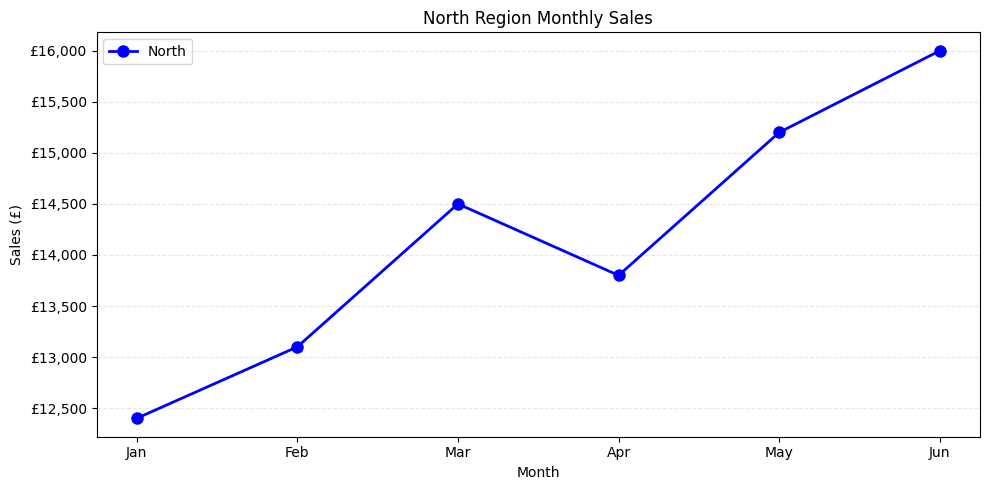

In [3]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

north = df_sales.loc[
    df_sales['region'] == 'North',
    months_cols
].values[0].tolist()

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    months,
    north,
    color='blue',
    linewidth=2,
    marker='o',
    markersize=8,
    linestyle='-',
    label='North'
)

ax.set_title('North Region Monthly Sales')
ax.set_xlabel('Month')
ax.set_ylabel('Sales (£)')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax.grid(axis='y', linestyle='--', alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

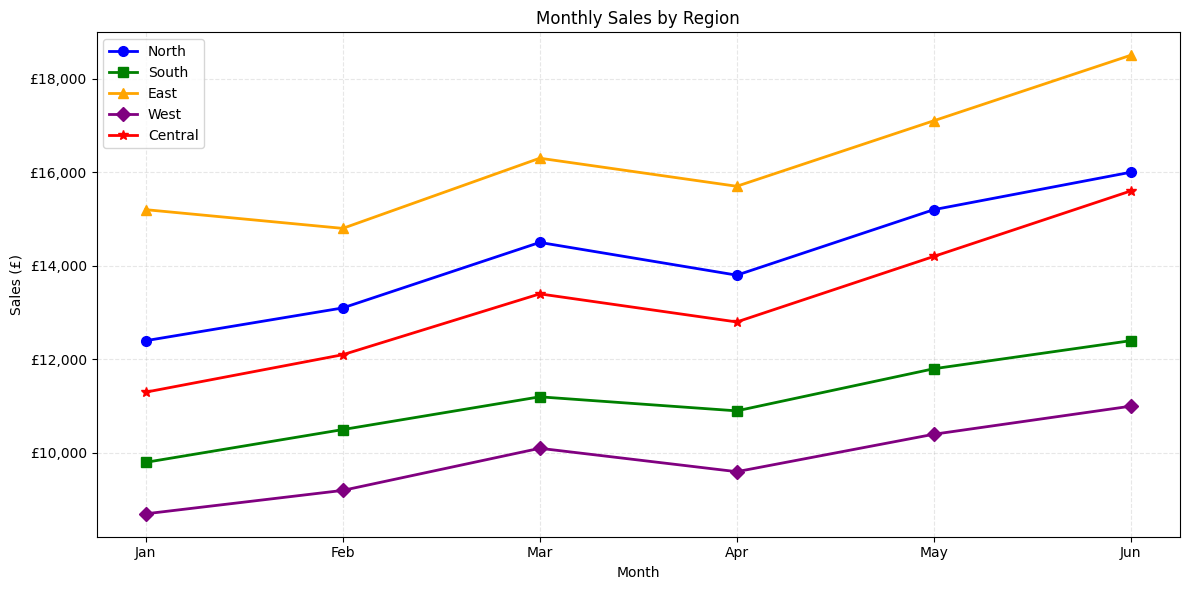

In [16]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

colors = ['blue', 'green', 'orange', 'purple', 'red']

markers = ['o', 's', '^', 'D', '*']

fig, ax = plt.subplots(figsize=(12,6))

for i, row in df_sales.iterrows():

    ax.plot(
        months,
        row[months_cols],
        color=colors[i],
        marker=markers[i],
        linewidth=2,
        markersize=7,
        label=row['region']
    )

ax.set_title('Monthly Sales by Region')
ax.set_xlabel('Month')
ax.set_ylabel('Sales (£)')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax.grid(alpha=0.3, linestyle='--')

ax.legend()

plt.tight_layout()
plt.show()

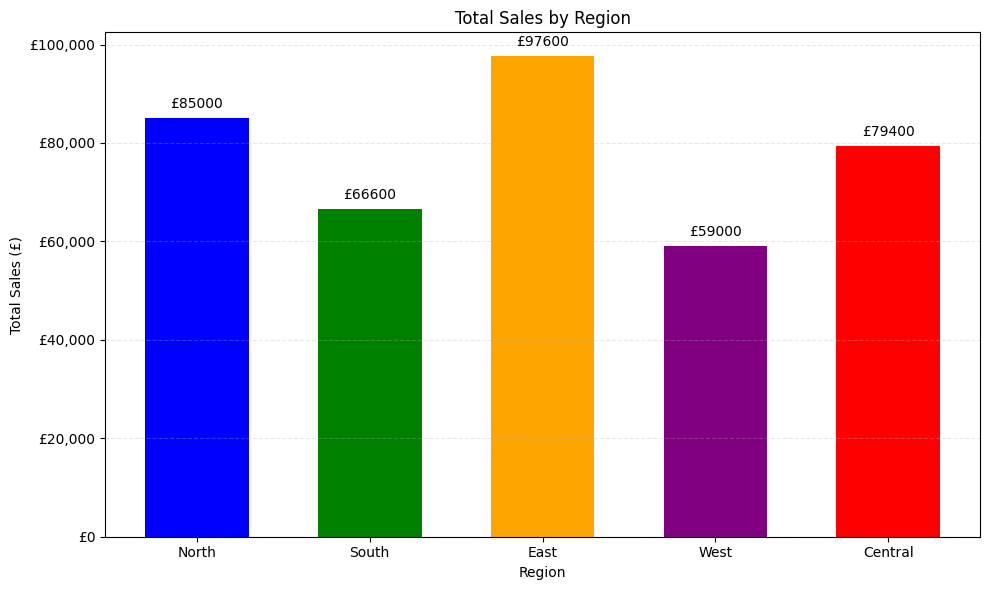

In [5]:
colors = ['blue', 'green', 'orange', 'purple', 'red']

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    df_sales['region'],
    df_sales['total_sales'],
    color=colors,
    width=0.6
)

ax.bar_label(
    bars,
    fmt='£%.0f',
    padding=5
)

ax.set_title('Total Sales by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales (£)')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

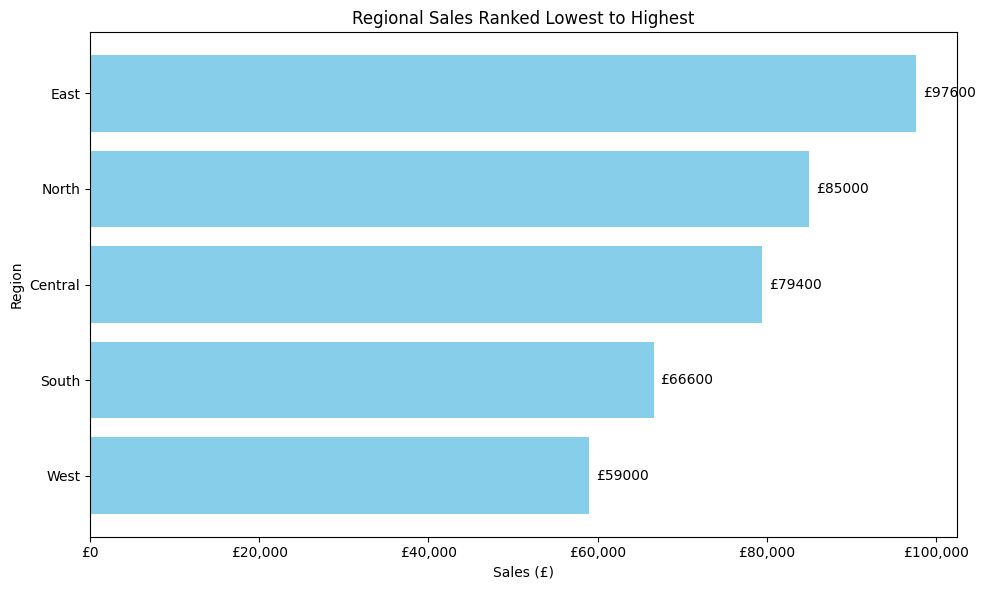

In [6]:
df_sorted = df_sales.sort_values('total_sales')

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    df_sorted['region'],
    df_sorted['total_sales'],
    color='skyblue'
)

ax.bar_label(
    bars,
    fmt='£%.0f',
    padding=5
)

ax.set_title('Regional Sales Ranked Lowest to Highest')
ax.set_xlabel('Sales (£)')
ax.set_ylabel('Region')

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

plt.tight_layout()
plt.show()

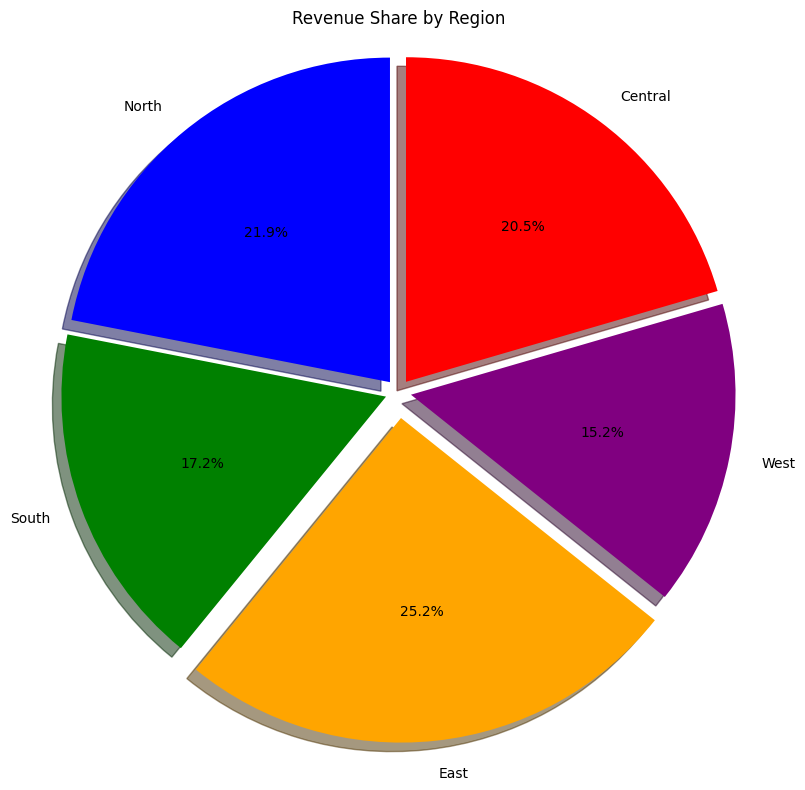

In [13]:
colors = ['blue', 'green', 'orange', 'purple', 'red']

explode = [0.04, 0.04, 0.08, 0.04, 0.04]

fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotexts = ax.pie(
    df_sales['total_sales'],
    labels=df_sales['region'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    shadow=True
)

ax.set_title('Revenue Share by Region')

plt.axis('equal')

plt.tight_layout()
plt.show()

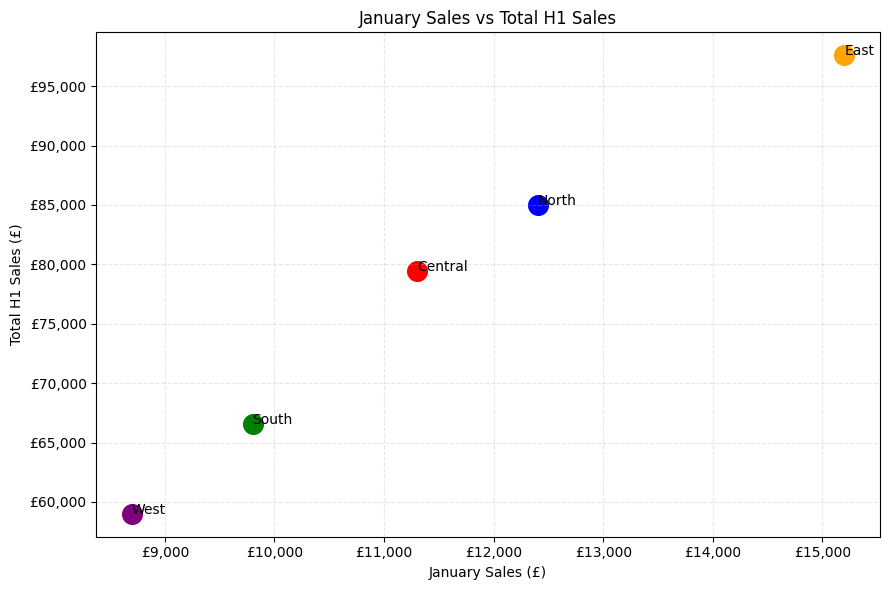

In [14]:
colors = ['blue', 'green', 'orange', 'purple', 'red']

fig, ax = plt.subplots(figsize=(9,6))

for i, row in df_sales.iterrows():

    ax.scatter(
        row['jan'],
        row['total_sales'],
        color=colors[i],
        s=200
    )

    ax.annotate(
        row['region'],
        (row['jan'], row['total_sales'])
    )

ax.set_title('January Sales vs Total H1 Sales')

ax.set_xlabel('January Sales (£)')
ax.set_ylabel('Total H1 Sales (£)')

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

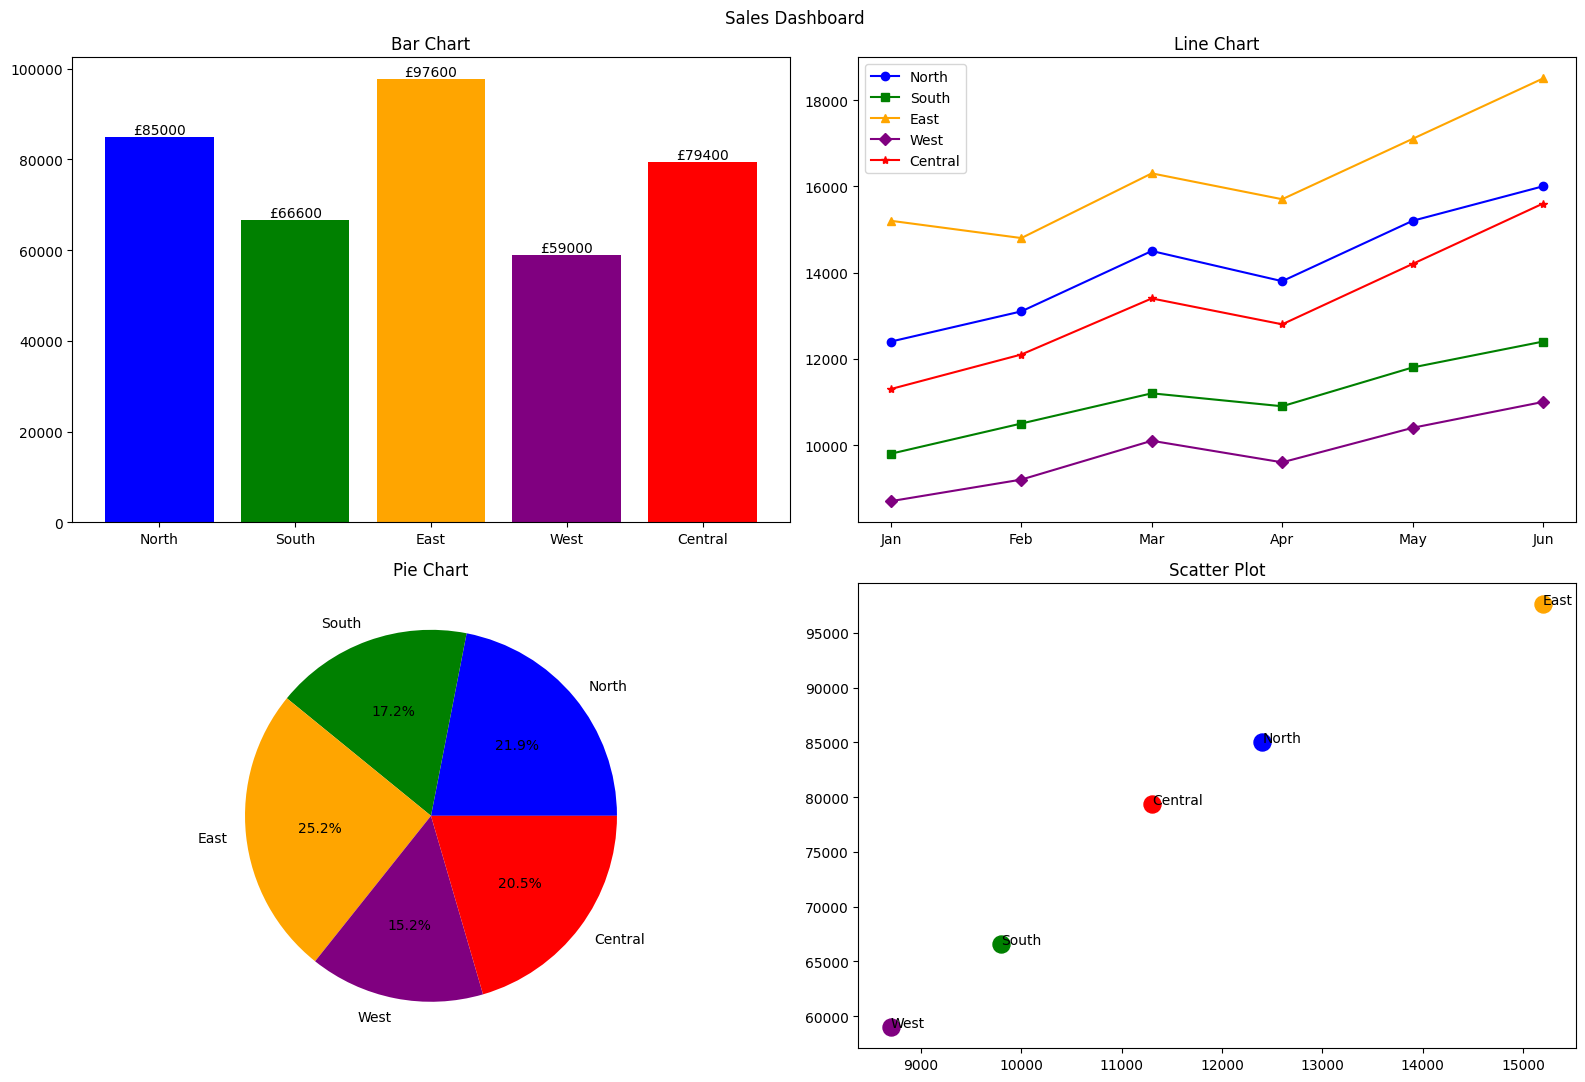

In [12]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

colors = ['blue', 'green', 'orange', 'purple', 'red']

markers = ['o', 's', '^', 'D', '*']

fig, axes = plt.subplots(2, 2, figsize=(16,11))

ax1, ax2, ax3, ax4 = axes.flatten()

# BAR CHART
bars = ax1.bar(
    df_sales['region'],
    df_sales['total_sales'],
    color=colors
)

ax1.bar_label(bars, fmt='£%.0f')

ax1.set_title('Bar Chart')

# LINE CHART
for i, row in df_sales.iterrows():

    ax2.plot(
        months,
        row[months_cols],
        color=colors[i],
        marker=markers[i],
        label=row['region']
    )

ax2.set_title('Line Chart')

ax2.legend()

# PIE CHART
ax3.pie(
    df_sales['total_sales'],
    labels=df_sales['region'],
    autopct='%1.1f%%',
    colors=colors
)

ax3.set_title('Pie Chart')

# SCATTER PLOT
for i, row in df_sales.iterrows():

    ax4.scatter(
        row['jan'],
        row['total_sales'],
        color=colors[i],
        s=150
    )

    ax4.annotate(
        row['region'],
        (row['jan'], row['total_sales'])
    )

ax4.set_title('Scatter Plot')

plt.suptitle('Sales Dashboard')

plt.tight_layout()

plt.show()